In [140]:
import io
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from PIL import Image
from google.colab import files
from google.colab import drive

import cv2

from PIL import Image, ImageOps

print("TensorFlow version:", tf.__version__)

import base64
import cv2
import io
import json
import openai

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image, ImageOps
from tensorflow import keras
from google.colab import files, userdata

TensorFlow version: 2.20.0


In [141]:
# Mount the instructor's Google Drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [142]:
%cd /content/drive/MyDrive/Everything USF/AI Summer Intensive 2026/Day 5

/content/drive/MyDrive/Everything USF/AI Summer Intensive 2026/Day 5


In [143]:
ls

'Live Demo.ipynb'   saved_models/


# Group 1

In [144]:
# ============================================================
# GROUP 1 — FAST FOOD AI
# CONFIGURATION
# ============================================================

GROUP_1_MODEL_PATH = (
    "saved_models/group_1_model.keras"
)

GROUP_1_CLASS_NAMES_PATH = (
    "saved_models/group_1_class_names.json"
)

GROUP_1_IMAGE_SIZE = 128

print("Group 1 configuration ready.")


# ============================================================
# GROUP 1 — LOAD THE TRAINED MODEL
# ============================================================

group_1_model_path = Path(
    GROUP_1_MODEL_PATH
)

if not group_1_model_path.exists():
    raise FileNotFoundError(
        f"Group 1 model was not found at:\n"
        f"{GROUP_1_MODEL_PATH}\n\n"
        "Check the filename and folder."
    )

group_1_model = keras.models.load_model(
    GROUP_1_MODEL_PATH,
    compile=False
)

print("Group 1 model loaded successfully.")
print("Input shape:", group_1_model.input_shape)
print("Output shape:", group_1_model.output_shape)

group_1_model.summary()


# ============================================================
# GROUP 1 — LOAD CLASS LABELS
# ============================================================

group_1_class_names_path = Path(
    GROUP_1_CLASS_NAMES_PATH
)

if not group_1_class_names_path.exists():
    raise FileNotFoundError(
        f"Group 1 class-name file was not found at:\n"
        f"{GROUP_1_CLASS_NAMES_PATH}"
    )

with open(
    group_1_class_names_path,
    "r",
    encoding="utf-8"
) as file:
    group_1_class_names = json.load(file)

print(
    "Group 1 classes:",
    group_1_class_names
)

if (
    group_1_model.output_shape[-1]
    != len(group_1_class_names)
):
    raise ValueError(
        "The number of model outputs does not match "
        "the number of class names."
    )

# ============================================================
# GROUP 1 — GRAD-CAM FUNCTIONS
# ============================================================

def group_1_gradcam_heatmap(
    image_uint8,
    trained_model,
    predicted_class_idx,
    layer_name="conv3"
):
    group_1_explanation_model = keras.Model(
        trained_model.inputs,
        [
            trained_model.get_layer(
                layer_name
            ).output,
            trained_model.output,
        ],
    )

    group_1_image_tensor = tf.convert_to_tensor(
        image_uint8[
            np.newaxis,
            ...
        ],
        dtype=tf.float32,
    )

    with tf.GradientTape() as tape:
        (
            group_1_feature_maps,
            group_1_class_probabilities
        ) = group_1_explanation_model(
            group_1_image_tensor,
            training=False,
        )

        group_1_score = (
            group_1_class_probabilities[
                0,
                predicted_class_idx
            ]
        )

    group_1_gradients = tape.gradient(
        group_1_score,
        group_1_feature_maps
    )

    group_1_importance = tf.reduce_mean(
        group_1_gradients,
        axis=(0, 1, 2)
    )

    group_1_feature_maps = (
        group_1_feature_maps[0]
    )

    group_1_heatmap = tf.reduce_sum(
        group_1_feature_maps
        * group_1_importance,
        axis=-1
    )

    group_1_heatmap = tf.maximum(
        group_1_heatmap,
        0
    )

    group_1_heatmap = (
        group_1_heatmap
        / (
            tf.reduce_max(
                group_1_heatmap
            )
            + 1e-8
        )
    )

    return group_1_heatmap.numpy()


def group_1_overlay_heatmap(
    image_uint8,
    heatmap,
    alpha=0.42
):
    group_1_resized = tf.image.resize(
        heatmap[
            ...,
            np.newaxis
        ],
        (
            GROUP_1_IMAGE_SIZE,
            GROUP_1_IMAGE_SIZE
        ),
    ).numpy().squeeze()

    group_1_colored = (
        plt.get_cmap("jet")(
            group_1_resized
        )[
            ...,
            :3
        ]
    )

    group_1_original = (
        image_uint8.astype(
            np.float32
        )
        / 255.0
    )

    return np.clip(
        (
            1 - alpha
        )
        * group_1_original
        + alpha
        * group_1_colored,
        0,
        1
    )


print(
    "Group 1 Grad-CAM functions are ready."
)

Group 1 configuration ready.
Group 1 model loaded successfully.
Input shape: (None, 128, 128, 3)
Output shape: (None, 5)


Model: "classroom_cat_dog_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 48)     │         6,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 48)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Dense)                │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,461 (44.77 KB)

 Trainable params: 11,461 (44.77 KB)

 Non-trainable params: 0 (0.00 B)

Group 1 classes: ['Crispy Chicken', 'Donut', 'Hot Dog', 'Pizza', 'Taco']
Group 1 Grad-CAM functions are ready.


Saving taco.jpg to taco.jpg
Uploaded file: taco.jpg
Image preprocessed successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted class: Taco
Confidence: 0.41


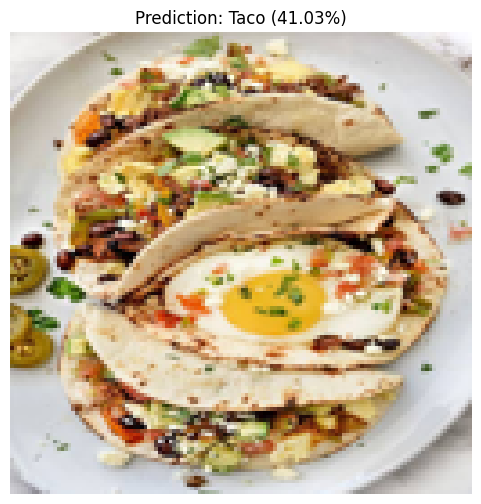

In [146]:
# ============================================================
# GROUP 1 — FAST FOOD IMAGE UPLOAD AND PREDICTION
# ============================================================

# Upload an image file
group_1_uploaded = files.upload()

# Get the filename of the uploaded image
group_1_uploaded_image_filename = None

for group_1_filename in group_1_uploaded.keys():
    group_1_uploaded_image_filename = (
        group_1_filename
    )
    break

if group_1_uploaded_image_filename is None:
    raise ValueError(
        "No image was uploaded."
    )

print(
    f"Uploaded file: "
    f"{group_1_uploaded_image_filename}"
)


# Load and preprocess the uploaded image
group_1_image_path = (
    group_1_uploaded_image_filename
)

group_1_img = Image.open(
    group_1_image_path
).convert(
    "RGB"
)

group_1_img = group_1_img.resize(
    (
        GROUP_1_IMAGE_SIZE,
        GROUP_1_IMAGE_SIZE
    )
)

group_1_img_array = np.array(
    group_1_img
)

# The model expects a batch of images,
# so add an extra dimension.
group_1_img_array = np.expand_dims(
    group_1_img_array,
    axis=0
)

# The Rescaling(1/255) layer is already
# included inside the saved model.
print(
    "Image preprocessed successfully."
)


# Make a prediction
group_1_predictions = (
    group_1_model.predict(
        group_1_img_array
    )
)

group_1_predicted_probabilities = (
    group_1_predictions[0]
)

# Get the predicted class and its confidence
group_1_predicted_class_idx = int(
    np.argmax(
        group_1_predicted_probabilities
    )
)

group_1_predicted_class_name = (
    group_1_class_names[
        group_1_predicted_class_idx
    ]
)

group_1_confidence = (
    group_1_predicted_probabilities[
        group_1_predicted_class_idx
    ]
)

print(
    f"Predicted class: "
    f"{group_1_predicted_class_name}"
)

print(
    f"Confidence: "
    f"{group_1_confidence:.2f}"
)

# Display the image with its prediction
plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    group_1_img
)

plt.title(
    f"Prediction: "
    f"{group_1_predicted_class_name} "
    f"({group_1_confidence:.2%})"
)

plt.axis(
    "off"
)

plt.show()

# Group 3

In [149]:
# ============================================================
# GROUP 3 — SPORTS BALL RECOGNITION
# CONFIGURATION
# ============================================================

GROUP_3_MODEL_PATH = (
    "saved_models/group_3_model.keras"
)

GROUP_3_CLASS_NAMES_PATH = (
    "saved_models/group_3_class_names.json"
)

GROUP_3_IMAGE_SIZE = (128, 128)

print("Group 3 configuration ready.")


# ============================================================
# GROUP 3 — LOAD THE TRAINED MODEL
# ============================================================

group_3_model_path = Path(
    GROUP_3_MODEL_PATH
)

if not group_3_model_path.exists():
    raise FileNotFoundError(
        f"Group 3 model was not found at:\n"
        f"{GROUP_3_MODEL_PATH}\n\n"
        "Check the filename and folder."
    )

group_3_model = keras.models.load_model(
    GROUP_3_MODEL_PATH,
    compile=False
)

print("Group 3 model loaded successfully.")
print("Input shape:", group_3_model.input_shape)
print("Output shape:", group_3_model.output_shape)

group_3_model.summary()


# ============================================================
# GROUP 3 — LOAD CLASS LABELS
# ============================================================

group_3_class_names_path = Path(
    GROUP_3_CLASS_NAMES_PATH
)

if not group_3_class_names_path.exists():
    raise FileNotFoundError(
        f"Group 3 class-name file was not found at:\n"
        f"{GROUP_3_CLASS_NAMES_PATH}"
    )

with open(
    group_3_class_names_path,
    "r",
    encoding="utf-8"
) as file:
    group_3_class_names = json.load(file)

print(
    "Group 3 classes:",
    group_3_class_names
)

if (
    group_3_model.output_shape[-1]
    != len(group_3_class_names)
):
    raise ValueError(
        "The number of model outputs does not match "
        "the number of class names."
    )

if tuple(
    group_3_model.input_shape[1:]
) != (128, 128, 3):
    raise ValueError(
        "The loaded Group 3 model does not expect "
        "images with shape (128, 128, 3)."
    )

# ============================================================
# GROUP 3 — GRAD-CAM FUNCTIONS
# ============================================================

def group_3_last_conv_layer(model):
    """Return the final Conv2D layer in the model."""
    for group_3_layer in reversed(
        model.layers
    ):
        if isinstance(
            group_3_layer,
            layers.Conv2D
        ):
            return group_3_layer

    raise ValueError(
        "Grad-CAM requires at least one Conv2D layer."
    )


def group_3_build_gradcam_model(
    model,
    image_shape
):
    """
    Create a functional model for Grad-CAM without
    relying on model.output.
    """
    group_3_target_conv_layer = (
        group_3_last_conv_layer(
            model
        )
    )

    group_3_symbolic_input = keras.Input(
        shape=image_shape,
        name="group_3_gradcam_input"
    )

    group_3_x = (
        group_3_symbolic_input
    )

    group_3_convolution_features = None

    for group_3_layer in model.layers:
        try:
            group_3_x = group_3_layer(
                group_3_x,
                training=False
            )
        except TypeError:
            group_3_x = group_3_layer(
                group_3_x
            )

        if (
            group_3_layer
            is group_3_target_conv_layer
        ):
            group_3_convolution_features = (
                group_3_x
            )

    if group_3_convolution_features is None:
        raise ValueError(
            "The final Conv2D layer was not connected "
            "to the prediction."
        )

    return keras.Model(
        inputs=group_3_symbolic_input,
        outputs=[
            group_3_convolution_features,
            group_3_x
        ],
        name="group_3_gradcam_model"
    )


def group_3_make_gradcam_heatmap(
    image_batch,
    model,
    class_index=None
):
    """Compute a normalized Grad-CAM heatmap."""
    group_3_grad_model = (
        group_3_build_gradcam_model(
            model,
            image_shape=tuple(
                image_batch.shape[1:]
            )
        )
    )

    with tf.GradientTape() as group_3_tape:
        (
            group_3_features,
            group_3_predictions
        ) = group_3_grad_model(
            image_batch,
            training=False
        )

        if class_index is None:
            class_index = tf.argmax(
                group_3_predictions[0]
            )

        group_3_selected_score = (
            group_3_predictions[
                :,
                class_index
            ]
        )

    group_3_gradients = (
        group_3_tape.gradient(
            group_3_selected_score,
            group_3_features
        )
    )

    if group_3_gradients is None:
        raise RuntimeError(
            "Gradients could not be computed. Check that "
            "the final Conv2D layer is connected to the output."
        )

    group_3_weights = tf.reduce_mean(
        group_3_gradients,
        axis=(0, 1, 2)
    )

    group_3_heatmap = tf.reduce_sum(
        group_3_features[0]
        * group_3_weights,
        axis=-1
    )

    group_3_heatmap = tf.maximum(
        group_3_heatmap,
        0
    )

    group_3_heatmap = (
        group_3_heatmap
        / (
            tf.reduce_max(
                group_3_heatmap
            )
            + keras.backend.epsilon()
        )
    )

    return (
        group_3_heatmap.numpy(),
        int(class_index)
    )


def group_3_show_gradcam(
    model,
    image,
    class_names
):
    """
    Show the image, Grad-CAM heatmap, and overlay.
    The image must already be normalized to [0,1].
    """
    if model is None:
        print(
            "Define and train the model first."
        )
        return

    group_3_image_batch = np.expand_dims(
        image,
        axis=0
    ).astype(
        "float32"
    )

    group_3_probabilities = (
        model.predict(
            group_3_image_batch,
            verbose=0
        )[0]
    )

    group_3_predicted_index = int(
        np.argmax(
            group_3_probabilities
        )
    )

    (
        group_3_heatmap,
        _
    ) = group_3_make_gradcam_heatmap(
        group_3_image_batch,
        model,
        class_index=group_3_predicted_index
    )

    group_3_resized_heatmap = (
        tf.image.resize(
            group_3_heatmap[
                ...,
                np.newaxis
            ],
            image.shape[:2]
        )
        .numpy()
        .squeeze()
    )

    group_3_display_image = np.clip(
        image,
        0,
        1
    )

    group_3_colored_heatmap = (
        plt.cm.jet(
            group_3_resized_heatmap
        )[
            ...,
            :3
        ]
    )

    group_3_overlay = np.clip(
        0.60 * group_3_display_image
        + 0.40 * group_3_colored_heatmap,
        0,
        1
    )

    group_3_title = (
        f"Predicted: "
        f"{class_names[group_3_predicted_index]} "
        f"({100 * group_3_probabilities[group_3_predicted_index]:.1f}%)"
    )

    plt.figure(
        figsize=(12, 4)
    )

    plt.subplot(
        1,
        3,
        1
    )

    plt.imshow(
        group_3_display_image
    )

    plt.title(
        "Original image"
    )

    plt.axis(
        "off"
    )

    plt.subplot(
        1,
        3,
        2
    )

    plt.imshow(
        group_3_resized_heatmap,
        cmap="jet"
    )

    plt.title(
        "Grad-CAM heatmap"
    )

    plt.axis(
        "off"
    )

    plt.subplot(
        1,
        3,
        3
    )

    plt.imshow(
        group_3_overlay
    )

    plt.title(
        group_3_title
    )

    plt.axis(
        "off"
    )

    plt.tight_layout()
    plt.show()


print(
    "Group 3 Grad-CAM functions are ready."
)

Group 3 configuration ready.
Group 3 model loaded successfully.
Input shape: (None, 128, 128, 3)
Output shape: (None, 5)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 398,821 (1.52 MB)

 Trainable params: 398,821 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Group 3 classes: ['american_football', 'baseball', 'basketball', 'football', 'tennis_ball']
Group 3 Grad-CAM functions are ready.


Upload an image of a sports ball:


Saving im1.jpg to im1.jpg
User uploaded file "im1.jpg"


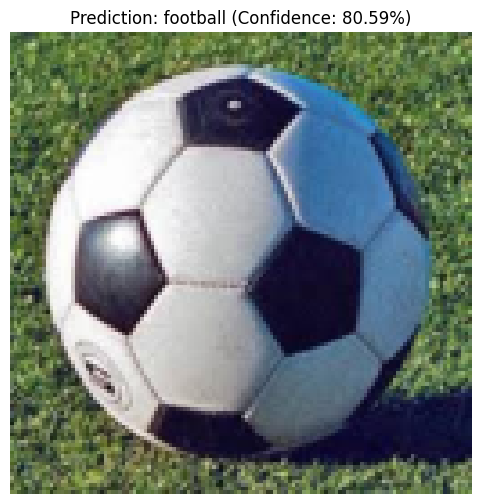

In [152]:
# ============================================================
# GROUP 3 — SPORTS BALL RECOGNITION LIVE DEMO
# ============================================================

print(
    "Upload an image of a sports ball:"
)

group_3_uploaded = files.upload()

if not group_3_uploaded:
    raise ValueError(
        "No image was uploaded."
    )

for group_3_filename in group_3_uploaded.keys():

    print(
        f'User uploaded file "{group_3_filename}"'
    )

    # Read and preprocess the image
    group_3_img = Image.open(
        io.BytesIO(
            group_3_uploaded[
                group_3_filename
            ]
        )
    )

    group_3_img = group_3_img.convert(
        "RGB"
    )

    group_3_img = group_3_img.resize(
        GROUP_3_IMAGE_SIZE,
        Image.Resampling.BILINEAR
    )

    group_3_img_array = np.asarray(
        group_3_img,
        dtype=np.uint8
    )

    # Match the team's training normalization
    group_3_img_normalized = (
        group_3_img_array.astype(
            np.float32
        )
        / 255.0
    )

    # Add batch dimension:
    # (128, 128, 3) -> (1, 128, 128, 3)
    group_3_img_batch = np.expand_dims(
        group_3_img_normalized,
        axis=0
    )

    # Make prediction
    group_3_predictions = (
        group_3_model.predict(
            group_3_img_batch,
            verbose=0
        )
    )

    group_3_predicted_class_index = int(
        np.argmax(
            group_3_predictions[0]
        )
    )

    group_3_predicted_class = (
        group_3_class_names[
            group_3_predicted_class_index
        ]
    )

    group_3_confidence = float(
        group_3_predictions[0][
            group_3_predicted_class_index
        ]
    )

    # Display the image and prediction
    plt.figure(
        figsize=(6, 6)
    )

    plt.imshow(
        group_3_img_array
    )

    plt.title(
        f"Prediction: "
        f"{group_3_predicted_class} "
        f"(Confidence: "
        f"{100 * group_3_confidence:.2f}%)"
    )

    plt.axis(
        "off"
    )

    plt.show()

In [ ]:
# ============================================================
# GROUP 3 — GRAD-CAM LIVE EXPLANATION
# ============================================================

group_3_show_gradcam(
    group_3_model,
    group_3_img_normalized,
    group_3_class_names
)

# Group 4

In [153]:
# ============================================================
# GROUP 4 — AI SATELLITE PROJECT
# CONFIGURATION
# ============================================================

GROUP_4_MODEL_PATH = (
    "saved_models/group_4_sip_model.keras"
)

GROUP_4_CLASS_NAMES_PATH = (
    "saved_models/group_4_sip_class_names.json"
)

GROUP_4_IMAGE_SIZE = (64, 64)

print("Group 4 configuration ready.")


# ============================================================
# GROUP 4 — LOAD THE TRAINED MODEL
# ============================================================

group_4_model_path = Path(
    GROUP_4_MODEL_PATH
)

if not group_4_model_path.exists():
    raise FileNotFoundError(
        f"Group 4 model was not found at:\n"
        f"{GROUP_4_MODEL_PATH}\n\n"
        "Check the filename and folder."
    )

group_4_model = keras.models.load_model(
    GROUP_4_MODEL_PATH,
    compile=False
)

print("Group 4 model loaded successfully.")
print("Input shape:", group_4_model.input_shape)
print("Output shape:", group_4_model.output_shape)

group_4_model.summary()


# ============================================================
# GROUP 4 — LOAD CLASS LABELS
# ============================================================

group_4_class_names_path = Path(
    GROUP_4_CLASS_NAMES_PATH
)

if group_4_class_names_path.exists():
    with open(
        group_4_class_names_path,
        "r",
        encoding="utf-8"
    ) as file:
        group_4_class_names = json.load(file)

    print("Loaded Group 4 class names from file.")

else:
    group_4_class_names = [
        "AnnualCrop",
        "Forest",
        "HerbaceousVegetation",
        "Highway",
        "Industrial",
        "Pasture",
        "PermanentCrop",
        "Residential",
        "River",
        "SeaLake"
    ]

    print("Class-name file not found.")
    print("Using the expected fallback class order.")

print(
    "Group 4 classes:",
    group_4_class_names
)

if (
    group_4_model.output_shape[-1]
    != len(group_4_class_names)
):
    raise ValueError(
        "The number of model outputs does not match "
        "the number of class names."
    )

# ============================================================
# GROUP 4 — GRAD-CAM FUNCTIONS
# ============================================================

def group_4_last_conv_layer(model):
    """Return the final Conv2D layer in a model."""
    for group_4_layer in reversed(
        model.layers
    ):
        if isinstance(
            group_4_layer,
            layers.Conv2D
        ):
            return group_4_layer

    raise ValueError(
        "Grad-CAM requires at least one Conv2D layer."
    )


def group_4_build_gradcam_model(
    model,
    image_shape
):
    """
    Create a functional model for Grad-CAM without
    relying on model.output.
    """
    group_4_target_conv_layer = (
        group_4_last_conv_layer(
            model
        )
    )

    group_4_symbolic_input = keras.Input(
        shape=image_shape,
        name="group_4_gradcam_input"
    )

    group_4_x = (
        group_4_symbolic_input
    )

    group_4_convolution_features = None

    for group_4_layer in model.layers:

        # Disable Dropout and random augmentation
        # while explaining an image.
        try:
            group_4_x = group_4_layer(
                group_4_x,
                training=False
            )
        except TypeError:
            group_4_x = group_4_layer(
                group_4_x
            )

        if (
            group_4_layer
            is group_4_target_conv_layer
        ):
            group_4_convolution_features = (
                group_4_x
            )

    if group_4_convolution_features is None:
        raise ValueError(
            "The final Conv2D layer was not connected "
            "to the prediction."
        )

    return keras.Model(
        inputs=group_4_symbolic_input,
        outputs=[
            group_4_convolution_features,
            group_4_x
        ],
        name="group_4_gradcam_model"
    )


def group_4_make_gradcam_heatmap(
    image_batch,
    model,
    class_index=None
):
    """Compute a normalized Grad-CAM heatmap."""
    group_4_grad_model = (
        group_4_build_gradcam_model(
            model,
            image_shape=tuple(
                image_batch.shape[1:]
            )
        )
    )

    with tf.GradientTape() as group_4_tape:
        (
            group_4_features,
            group_4_predictions
        ) = group_4_grad_model(
            image_batch,
            training=False
        )

        if class_index is None:
            class_index = tf.argmax(
                group_4_predictions[0]
            )

        group_4_selected_score = (
            group_4_predictions[
                :,
                class_index
            ]
        )

    group_4_gradients = (
        group_4_tape.gradient(
            group_4_selected_score,
            group_4_features
        )
    )

    if group_4_gradients is None:
        raise RuntimeError(
            "Gradients could not be computed. "
            "Check that the CNN's final Conv2D "
            "layer is connected to the output."
        )

    group_4_weights = tf.reduce_mean(
        group_4_gradients,
        axis=(0, 1, 2)
    )

    group_4_heatmap = tf.reduce_sum(
        group_4_features[0]
        * group_4_weights,
        axis=-1
    )

    group_4_heatmap = tf.maximum(
        group_4_heatmap,
        0
    )

    group_4_heatmap = (
        group_4_heatmap
        / (
            tf.reduce_max(
                group_4_heatmap
            )
            + keras.backend.epsilon()
        )
    )

    return (
        group_4_heatmap.numpy(),
        int(class_index)
    )


def group_4_show_gradcam(
    model,
    image,
    class_names
):
    """
    Show the normalized satellite image,
    Grad-CAM heatmap, and overlay.
    """
    if model is None:
        print(
            "Define and train the model first."
        )
        return

    group_4_image_batch = np.expand_dims(
        image,
        axis=0
    ).astype(
        "float32"
    )

    group_4_probabilities = (
        model.predict(
            group_4_image_batch,
            verbose=0
        )[0]
    )

    group_4_predicted_index = int(
        np.argmax(
            group_4_probabilities
        )
    )

    (
        group_4_heatmap,
        _
    ) = group_4_make_gradcam_heatmap(
        group_4_image_batch,
        model,
        class_index=group_4_predicted_index
    )

    group_4_resized_heatmap = (
        tf.image.resize(
            group_4_heatmap[
                ...,
                np.newaxis
            ],
            image.shape[:2]
        )
        .numpy()
        .squeeze()
    )

    group_4_display_image = np.clip(
        image,
        0,
        1
    )

    group_4_colored_heatmap = (
        plt.cm.jet(
            group_4_resized_heatmap
        )[
            ...,
            :3
        ]
    )

    group_4_overlay = np.clip(
        0.60 * group_4_display_image
        + 0.40 * group_4_colored_heatmap,
        0,
        1
    )

    group_4_title = (
        f"Predicted: "
        f"{class_names[group_4_predicted_index]} "
        f"({100 * group_4_probabilities[group_4_predicted_index]:.1f}%)"
    )

    plt.figure(
        figsize=(12, 4)
    )

    plt.subplot(
        1,
        3,
        1
    )

    plt.imshow(
        group_4_display_image
    )

    plt.title(
        "Original image"
    )

    plt.axis(
        "off"
    )

    plt.subplot(
        1,
        3,
        2
    )

    plt.imshow(
        group_4_resized_heatmap,
        cmap="jet"
    )

    plt.title(
        "Grad-CAM heatmap"
    )

    plt.axis(
        "off"
    )

    plt.subplot(
        1,
        3,
        3
    )

    plt.imshow(
        group_4_overlay
    )

    plt.title(
        group_4_title
    )

    plt.axis(
        "off"
    )

    plt.tight_layout()
    plt.show()


print(
    "Group 4 Grad-CAM functions are ready."
)

Group 4 configuration ready.
Group 4 model loaded successfully.
Input shape: (None, 64, 64, 3)
Output shape: (None, 10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,495,658 (5.71 MB)

 Trainable params: 1,495,658 (5.71 MB)

 Non-trainable params: 0 (0.00 B)

Loaded Group 4 class names from file.
Group 4 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Group 4 Grad-CAM functions are ready.


Upload one satellite image:


Saving im3.png to im3.png
User uploaded file "im3.png"
Predicted class: AnnualCrop
Confidence: 100.00%


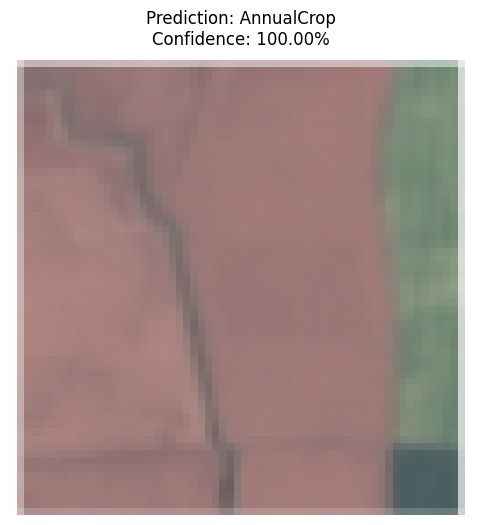

In [156]:
# ============================================================
# GROUP 4 — SATELLITE IMAGE LIVE DEMO
# ============================================================

print(
    "Upload one satellite image:"
)

group_4_uploaded = files.upload()

if not group_4_uploaded:
    raise ValueError(
        "No image was uploaded."
    )

group_4_filename = next(
    iter(
        group_4_uploaded
    )
)

print(
    f'User uploaded file "{group_4_filename}"'
)


# ============================================================
# READ AND PREPROCESS THE IMAGE
# ============================================================

group_4_img = Image.open(
    io.BytesIO(
        group_4_uploaded[
            group_4_filename
        ]
    )
)

group_4_img = group_4_img.convert(
    "RGB"
)

group_4_img = group_4_img.resize(
    GROUP_4_IMAGE_SIZE,
    Image.Resampling.BILINEAR
)

group_4_img_array = np.asarray(
    group_4_img,
    dtype=np.uint8
)

# Match the team's training preprocessing.
group_4_img_normalized = (
    group_4_img_array.astype(
        np.float32
    )
    / 255.0
)

group_4_img_batch = np.expand_dims(
    group_4_img_normalized,
    axis=0
)


# ============================================================
# MAKE THE PREDICTION
# ============================================================

group_4_predictions = (
    group_4_model.predict(
        group_4_img_batch,
        verbose=0
    )
)

group_4_predicted_class_index = int(
    np.argmax(
        group_4_predictions[0]
    )
)

group_4_predicted_class = (
    group_4_class_names[
        group_4_predicted_class_index
    ]
)

group_4_confidence = float(
    group_4_predictions[0][
        group_4_predicted_class_index
    ]
)

print(
    f"Predicted class: "
    f"{group_4_predicted_class}"
)

print(
    f"Confidence: "
    f"{100 * group_4_confidence:.2f}%"
)


# ============================================================
# DISPLAY THE UPLOADED IMAGE
# ============================================================

plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    group_4_img
)

plt.title(
    f"Prediction: "
    f"{group_4_predicted_class}\n"
    f"Confidence: "
    f"{100 * group_4_confidence:.2f}%"
)

plt.axis(
    "off"
)

plt.show()

# Group 5

In [157]:
# ============================================================
# GROUP 5 — ROCK, PAPER, SCISSORS
# CONFIGURATION
# ============================================================

GROUP_5_MODEL_PATH = (
    "saved_models/group_5_rps_model.keras"
)

GROUP_5_CLASS_NAMES_PATH = (
    "saved_models/group_5_class_names.json"
)

GROUP_5_IMAGE_SIZE = (64, 64)

print("Group 5 configuration ready.")

# ============================================================
# GROUP 5 — LOAD THE TRAINED MODEL
# ============================================================

group_5_model_path = Path(GROUP_5_MODEL_PATH)

if not group_5_model_path.exists():
    raise FileNotFoundError(
        f"Group 5 model was not found at:\n{GROUP_5_MODEL_PATH}\n\n"
        "Check the filename and Google Drive folder."
    )

group_5_model = keras.models.load_model(
    GROUP_5_MODEL_PATH,
    compile=False
)

print("Group 5 model loaded successfully.")
print("Input shape:", group_5_model.input_shape)
print("Output shape:", group_5_model.output_shape)

group_5_model.summary()

# ============================================================
# GROUP 5 — LOAD CLASS LABELS
# ============================================================

group_5_class_names_path = Path(GROUP_5_CLASS_NAMES_PATH)

if group_5_class_names_path.exists():
    with open(group_5_class_names_path, "r", encoding="utf-8") as file:
        group_5_class_names = json.load(file)

    print("Loaded class names from file.")
else:
    # Fallback based on the original Group 5 dataset-loading order
    group_5_class_names = ["paper", "rock", "scissors"]

    print("Class-name file not found.")
    print("Using the expected fallback class order.")

print("Group 5 classes:", group_5_class_names)

if group_5_model.output_shape[-1] != len(group_5_class_names):
    raise ValueError(
        "The number of model outputs does not match the number "
        "of class names."
    )

# ============================================================
# GROUP 5 — PREPROCESSING AND PREDICTION FUNCTIONS
# ============================================================

def preprocess_group_5_image(image):
    """
    Prepare one image for the Group 5 model.

    Steps:
    1. Convert to RGB.
    2. Resize to 64 x 64.
    3. Convert to float32.
    4. Normalize pixel values to the range 0–1.
    5. Add the batch dimension.
    """
    image = image.convert("RGB")

    display_image = image.copy()

    model_image = image.resize(
        GROUP_5_IMAGE_SIZE,
        Image.Resampling.BILINEAR
    )

    image_array = np.asarray(
        model_image,
        dtype=np.float32
    )

    image_array = image_array / 255.0

    image_batch = np.expand_dims(
        image_array,
        axis=0
    )

    return image_batch, display_image


def predict_group_5_image(image):
    """
    Return the predicted class, confidence, and all probabilities.
    """
    image_batch, display_image = preprocess_group_5_image(image)

    probabilities = group_5_model.predict(
        image_batch,
        verbose=0
    )[0]

    predicted_index = int(np.argmax(probabilities))
    predicted_class = group_5_class_names[predicted_index]
    confidence = float(probabilities[predicted_index])

    return {
        "display_image": display_image,
        "predicted_index": predicted_index,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "probabilities": probabilities
    }

print("Group 5 prediction functions are ready.")

Group 5 configuration ready.
Group 5 model loaded successfully.
Input shape: (None, 64, 64, 3)
Output shape: (None, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │        49,155 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,547 (267.76 KB)

 Trainable params: 68,547 (267.76 KB)

 Non-trainable params: 0 (0.00 B)

Loaded class names from file.
Group 5 classes: ['paper', 'rock', 'scissors']
Group 5 prediction functions are ready.


Upload an image of rock, paper, or scissors:


Saving unnamed (1).jpg to unnamed (1).jpg

The AI will now randomly select rock, paper, or scissors.
The AI has chosen paper.

User uploaded file "unnamed (1).jpg"


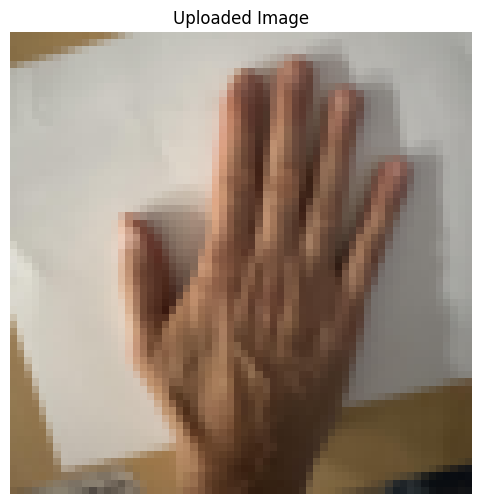

Prediction: paper
Prediction probability: 81.85%

You chose paper!

It's a tie!


In [158]:
# ============================================================
# GROUP 5 — ROCK, PAPER, SCISSORS LIVE GAME
# ============================================================

from google.colab import files
import io
import sys
import time
import random

group_5_signs = ["rock", "paper", "scissors"]
group_5_chosen_sign = random.choice(group_5_signs)

print("Upload an image of rock, paper, or scissors:")

group_5_uploaded = files.upload()

print(
    "\nThe AI will now randomly select "
    "rock, paper, or scissors."
)

time.sleep(1)

print(
    f"The AI has chosen "
    f"{group_5_chosen_sign}."
)

time.sleep(0.5)

for group_5_filename in group_5_uploaded.keys():

    print(
        f'\nUser uploaded file "{group_5_filename}"'
    )

    # Read and preprocess the image
    group_5_img = Image.open(
        io.BytesIO(
            group_5_uploaded[
                group_5_filename
            ]
        )
    )

    group_5_img = group_5_img.convert("RGB")

    group_5_img = group_5_img.resize(
        (64, 64),
        Image.Resampling.BILINEAR
    )

    group_5_img_array = np.asarray(
        group_5_img,
        dtype=np.uint8
    )

    # Normalize pixel values to the range 0–1
    group_5_img_normalized = (
        group_5_img_array.astype("float32")
        / 255.0
    )

    # Add batch dimension:
    # (64, 64, 3) -> (1, 64, 64, 3)
    group_5_img_batch = np.expand_dims(
        group_5_img_normalized,
        axis=0
    )

    # Make prediction
    group_5_predictions = (
        group_5_model.predict(
            group_5_img_batch,
            verbose=0
        )
    )

    group_5_predicted_class_index = int(
        np.argmax(
            group_5_predictions[0]
        )
    )

    group_5_predicted_class = (
        group_5_class_names[
            group_5_predicted_class_index
        ]
    )

    group_5_confidence = float(
        group_5_predictions[0][
            group_5_predicted_class_index
        ]
    )

    # Display the uploaded image
    plt.figure(figsize=(6, 6))

    plt.imshow(
        group_5_img_array
    )

    plt.title(
        "Uploaded Image"
    )

    plt.axis(
        "off"
    )

    plt.show()

    # Print prediction and probability
    print(
        f"Prediction: "
        f"{group_5_predicted_class}"
    )

    print(
        f"Prediction probability: "
        f"{100 * group_5_confidence:.2f}%\n"
    )

    if group_5_confidence > 0.70:
        print(
            f"You chose "
            f"{group_5_predicted_class}!\n"
        )

    else:
        print(
            "I'm not sure about your guess. "
            "Please try again with a new image."
        )
        sys.exit()

    if (
        group_5_predicted_class
        == group_5_chosen_sign
    ):
        print("It's a tie!")

    elif (
        (
            group_5_predicted_class == "rock"
            and group_5_chosen_sign == "scissors"
        )
        or
        (
            group_5_predicted_class == "scissors"
            and group_5_chosen_sign == "paper"
        )
        or
        (
            group_5_predicted_class == "paper"
            and group_5_chosen_sign == "rock"
        )
    ):
        print("You win!")

    else:
        print("AI wins!")

# Group 6

In [159]:
# ============================================================
# GROUP 6 — AI PICTIONARY
# CONFIGURATION
# ============================================================

GROUP_6_MODEL_PATH = (
    "saved_models/group_6_pictionary_model.keras"
)

GROUP_6_CLASS_NAMES_PATH = (
    "saved_models/group_6_class_names.json"
)

print("Group 6 configuration ready.")


# ============================================================
# GROUP 6 — LOAD THE TRAINED MODEL
# ============================================================

group_6_model_path = Path(
    GROUP_6_MODEL_PATH
)

if not group_6_model_path.exists():
    raise FileNotFoundError(
        f"Group 6 model was not found at:\n"
        f"{GROUP_6_MODEL_PATH}\n\n"
        "Check the filename and folder."
    )

group_6_model = keras.models.load_model(
    GROUP_6_MODEL_PATH,
    compile=False
)

print("Group 6 model loaded successfully.")
print("Input shape:", group_6_model.input_shape)
print("Output shape:", group_6_model.output_shape)

group_6_model.summary()


# ============================================================
# GROUP 6 — LOAD CLASS LABELS
# ============================================================

group_6_class_names_path = Path(
    GROUP_6_CLASS_NAMES_PATH
)

if group_6_class_names_path.exists():
    with open(
        group_6_class_names_path,
        "r",
        encoding="utf-8"
    ) as file:
        group_6_class_names = json.load(file)

    print("Loaded class names from file.")

else:
    group_6_class_names = [
        "apple",
        "bicycle",
        "cat",
        "fish",
        "flower",
        "house",
        "ice cream",
        "star",
        "tree",
        "umbrella"
    ]

    print("Class-name file not found.")
    print("Using the expected fallback class order.")

print(
    "Group 6 classes:",
    group_6_class_names
)

if (
    group_6_model.output_shape[-1]
    != len(group_6_class_names)
):
    raise ValueError(
        "The number of model outputs does not match "
        "the number of class names."
    )

# ============================================================
# GROUP 6 — PHOTOGRAPH PREPROCESSING
# ============================================================

def group_6_center_by_mass(image):
    """Shift a white-on-black drawing toward the canvas center."""
    moments = cv2.moments(image)

    if moments["m00"] == 0:
        return image

    center_x = moments["m10"] / moments["m00"]
    center_y = moments["m01"] / moments["m00"]
    desired_center = (image.shape[0] - 1) / 2

    shift_x = int(
        round(desired_center - center_x)
    )

    shift_y = int(
        round(desired_center - center_y)
    )

    matrix = np.float32([
        [1, 0, shift_x],
        [0, 1, shift_y],
    ])

    return cv2.warpAffine(
        image,
        matrix,
        (
            image.shape[1],
            image.shape[0]
        ),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )


def group_6_preprocess_drawing_photo(filename):
    """Convert a dark-on-white drawing photograph into a 28x28 doodle."""
    with Image.open(filename) as image:
        image = ImageOps.exif_transpose(
            image
        )

        original_rgb = np.asarray(
            image.convert("RGB")
        )

        grayscale = np.asarray(
            image.convert("L")
        )

    blurred = cv2.GaussianBlur(
        grayscale,
        (5, 5),
        0
    )

    _, binary = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY_INV
        + cv2.THRESH_OTSU
    )

    (
        number_of_components,
        component_map,
        stats,
        _
    ) = cv2.connectedComponentsWithStats(
        binary,
        connectivity=8
    )

    cleaned = np.zeros_like(
        binary
    )

    minimum_area = max(
        8,
        int(binary.size * 0.0005)
    )

    for component_index in range(
        1,
        number_of_components
    ):
        area = stats[
            component_index,
            cv2.CC_STAT_AREA
        ]

        if area >= minimum_area:
            cleaned[
                component_map
                == component_index
            ] = 255

    nonzero = cv2.findNonZero(
        cleaned
    )

    if nonzero is None:
        raise ValueError(
            "No dark drawing was detected. Use a darker marker "
            "and a plain, well-lit background."
        )

    x, y, width, height = cv2.boundingRect(
        nonzero
    )

    padding = max(
        4,
        int(
            round(
                0.08
                * max(width, height)
            )
        )
    )

    left = max(
        0,
        x - padding
    )

    top = max(
        0,
        y - padding
    )

    right = min(
        cleaned.shape[1],
        x + width + padding
    )

    bottom = min(
        cleaned.shape[0],
        y + height + padding
    )

    cropped = cleaned[
        top:bottom,
        left:right
    ]

    inner_size = 20

    scale = min(
        inner_size / cropped.shape[1],
        inner_size / cropped.shape[0]
    )

    resized_width = max(
        1,
        int(
            round(
                cropped.shape[1]
                * scale
            )
        )
    )

    resized_height = max(
        1,
        int(
            round(
                cropped.shape[0]
                * scale
            )
        )
    )

    resized = cv2.resize(
        cropped,
        (
            resized_width,
            resized_height
        ),
        interpolation=cv2.INTER_AREA
    )

    canvas = np.zeros(
        (28, 28),
        dtype=np.uint8
    )

    x_start = (
        28 - resized_width
    ) // 2

    y_start = (
        28 - resized_height
    ) // 2

    canvas[
        y_start:
        y_start + resized_height,

        x_start:
        x_start + resized_width
    ] = resized

    processed_28x28 = (
        group_6_center_by_mass(
            canvas
        )
    )

    return {
        "original_rgb": original_rgb,
        "grayscale": grayscale,
        "binary": binary,
        "cleaned": cleaned,
        "cropped": cropped,
        "processed_28x28":
            processed_28x28,
    }


def group_6_show_preprocessing_stages(
    result
):
    stage_names = [
        "Original photograph",
        "Grayscale",
        "Thresholded and inverted",
        "Cleaned",
        "Cropped drawing",
        "Final 28 × 28 input",
    ]

    stage_images = [
        result["original_rgb"],
        result["grayscale"],
        result["binary"],
        result["cleaned"],
        result["cropped"],
        result["processed_28x28"],
    ]

    plt.figure(
        figsize=(15, 8)
    )

    for position, (
        name,
        image
    ) in enumerate(
        zip(
            stage_names,
            stage_images
        ),
        start=1
    ):
        plt.subplot(
            2,
            3,
            position
        )

        if image.ndim == 2:
            plt.imshow(
                image,
                cmap="gray",
                vmin=0,
                vmax=255
            )
        else:
            plt.imshow(
                image
            )

        plt.title(
            name
        )

        plt.axis(
            "off"
        )

    plt.tight_layout()
    plt.show()

# ============================================================
# GROUP 6 — CNN PREDICTION FUNCTIONS
# ============================================================

# STUDENT CUSTOMIZATION:
# Raise this threshold to make the system more cautious.

GROUP_6_CONFIDENCE_THRESHOLD = 0.68


def group_6_predict_processed_drawing(
    processed_image,
    top_k=3
):
    """Return the highest-probability guesses for one 28x28 drawing."""
    if group_6_model is None:
        print(
            "Define and train the model first."
        )
        return None

    processed_image = np.asarray(
        processed_image
    )

    if processed_image.shape != (28, 28):
        raise ValueError(
            "processed_image must have shape (28, 28)."
        )

    model_input = (
        processed_image.astype(
            "float32"
        )
        / 255.0
    )

    model_input = model_input[
        np.newaxis,
        ...,
        np.newaxis,
    ]

    probabilities = (
        group_6_model.predict(
            model_input,
            verbose=0
        )[0]
    )

    top_indices = np.argsort(
        probabilities
    )[::-1][:top_k]

    top_guesses = [
        {
            "category":
                group_6_class_names[
                    int(index)
                ],
            "probability":
                float(
                    probabilities[index]
                ),
        }
        for index in top_indices
    ]

    return {
        "model_input": model_input,
        "top_guesses": top_guesses,
        "accepted": (
            top_guesses[0]["probability"]
            >= GROUP_6_CONFIDENCE_THRESHOLD
        ),
    }


def group_6_upload_and_predict_drawing():
    """Upload, preprocess, and classify one drawing photograph."""
    if group_6_model is None:
        print(
            "Define and train the model first."
        )
        return None

    try:
        from google.colab import files
    except ModuleNotFoundError:
        print(
            "The upload button in this cell is designed "
            "for Google Colab."
        )
        return None

    print(
        "Upload one JPEG or PNG photograph of a drawing."
    )

    group_6_uploaded_files = files.upload()

    if not group_6_uploaded_files:
        print(
            "No file was uploaded."
        )
        return None

    group_6_filename = next(
        iter(
            group_6_uploaded_files
        )
    )

    # Colab normally saves the uploaded file automatically.
    # This fallback guarantees that it exists on disk.
    if not Path(
        group_6_filename
    ).exists():
        Path(
            group_6_filename
        ).write_bytes(
            group_6_uploaded_files[
                group_6_filename
            ]
        )

    group_6_preprocessing = (
        group_6_preprocess_drawing_photo(
            group_6_filename
        )
    )

    group_6_show_preprocessing_stages(
        group_6_preprocessing
    )

    group_6_prediction = (
        group_6_predict_processed_drawing(
            group_6_preprocessing[
                "processed_28x28"
            ],
            top_k=3
        )
    )

    if group_6_prediction is None:
        return None

    print(
        "\nTop guesses:"
    )

    for rank, guess in enumerate(
        group_6_prediction[
            "top_guesses"
        ],
        start=1
    ):
        print(
            f"{rank}. {guess['category']}: "
            f"{100 * guess['probability']:.1f}%"
        )

    if group_6_prediction[
        "accepted"
    ]:
        print(
            "\nThe top confidence passed the chosen threshold."
        )
    else:
        print(
            "\nLow-confidence guess: the drawing may be unclear "
            "or unlike the training doodles."
        )

    return {
        **group_6_prediction,
        "filename":
            group_6_filename,
        "preprocessing":
            group_6_preprocessing,
    }


print(
    "Group 6 prediction functions are ready."
)

# ============================================================
# GROUP 6 — OPENAI FALLBACK
# ============================================================

group_6_openai_api_key = userdata.get(
    "OPENAI_API_KEY"
)

openai.api_key = (
    group_6_openai_api_key
)

GROUP_6_CATEGORIES = [
    "apple",
    "bicycle",
    "cat",
    "fish",
    "flower",
    "house",
    "ice cream",
    "star",
    "tree",
    "umbrella"
]


def group_6_verify_with_gpt(
    image_path,
    cnn_top3
):
    with open(
        image_path,
        "rb"
    ) as file:
        group_6_b64_image = (
            base64.b64encode(
                file.read()
            ).decode(
                "utf-8"
            )
        )

    group_6_response = (
        openai.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text":
                            f"This is a simple doodle. My CNN's top 3 guesses were {cnn_top3}. "
                            f"Given only these categories: {GROUP_6_CATEGORIES}, which one best matches the drawing? "
                            f"If none fit well, say 'none'. Reply with one word only."
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url":
                                f"data:image/png;base64,{group_6_b64_image}"
                        }
                    }
                ]
            }],
            max_tokens=30
        )
    )

    return (
        group_6_response
        .choices[0]
        .message
        .content
        .strip()
    )


print(
    "Group 6 OpenAI fallback is ready."
)

Group 6 configuration ready.
Group 6 model loaded successfully.
Input shape: (None, 28, 28, 1)
Output shape: (None, 10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Loaded class names from file.
Group 6 classes: ['apple', 'bicycle', 'cat', 'fish', 'flower', 'house', 'ice cream', 'star', 'tree', 'umbrella']
Group 6 prediction functions are ready.
Group 6 OpenAI fallback is ready.


Upload one JPEG or PNG photograph of a drawing.


Saving flower3.png to flower3.png


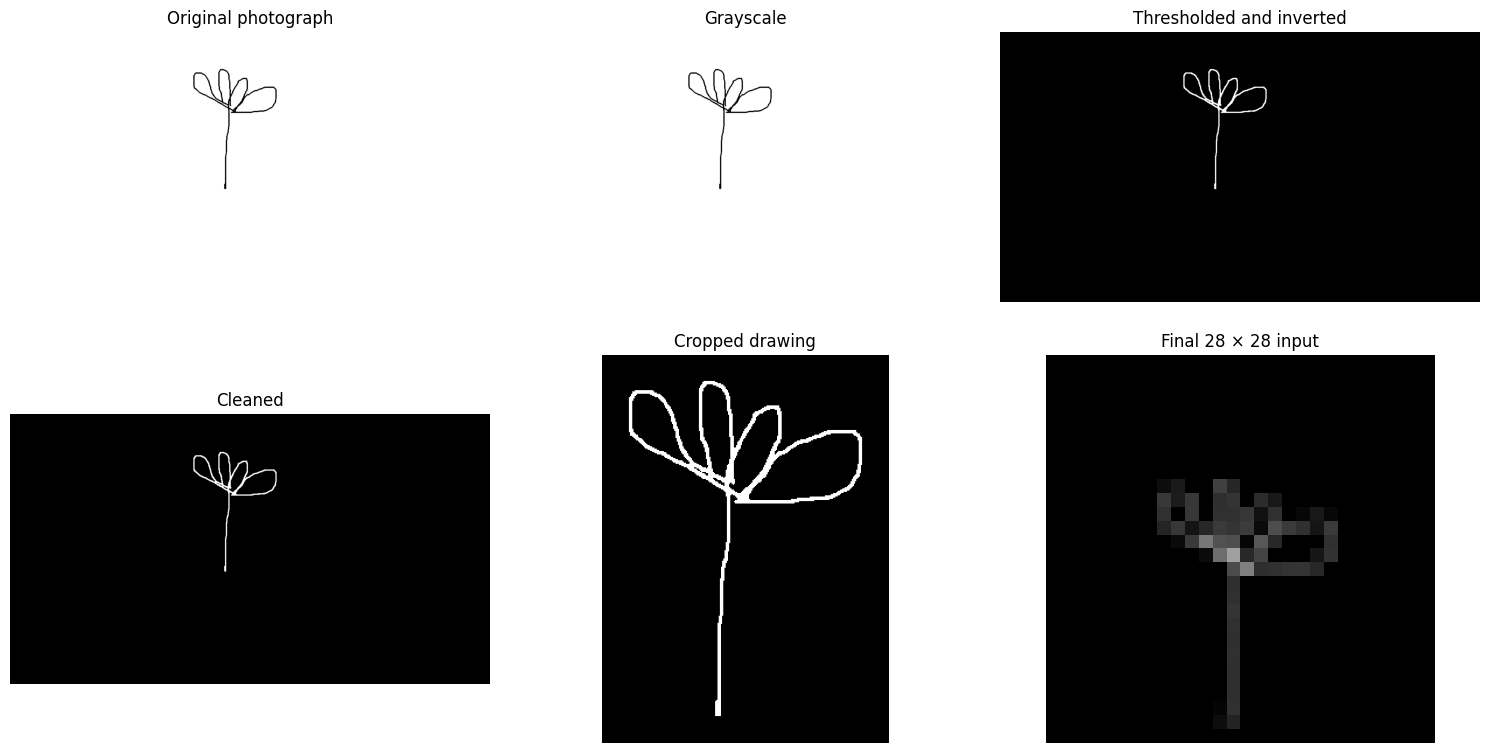


Top guesses:
1. flower: 25.3%
2. fish: 15.3%
3. umbrella: 11.7%

Low-confidence guess: the drawing may be unclear or unlike the training doodles.
CNN unsure — AI suggests: flower


In [161]:
# ============================================================
# GROUP 6 — AI PICTIONARY LIVE DEMO
# ============================================================

# Run this cell to test one drawing.

group_6_photo_prediction = (
    group_6_upload_and_predict_drawing()
)

if group_6_photo_prediction is not None:

    group_6_top3_preds = (
        group_6_photo_prediction[
            "top_guesses"
        ]
    )

    group_6_image_path = (
        group_6_photo_prediction[
            "filename"
        ]
    )

    if (
        group_6_top3_preds[0][
            "probability"
        ]
        < 0.5
    ):
        group_6_gpt_guess = (
            group_6_verify_with_gpt(
                group_6_image_path,
                [
                    prediction["category"]
                    for prediction
                    in group_6_top3_preds
                ]
            )
        )

        print(
            f"CNN unsure — AI suggests: "
            f"{group_6_gpt_guess}"
        )